In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

prsa_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.2%20numeric%20features/data/PRSA_Data.csv")
prsa_data[prsa_data == -1] = np.nan

is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)

undef = prsa_data.isnull().sum(axis=1)
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.

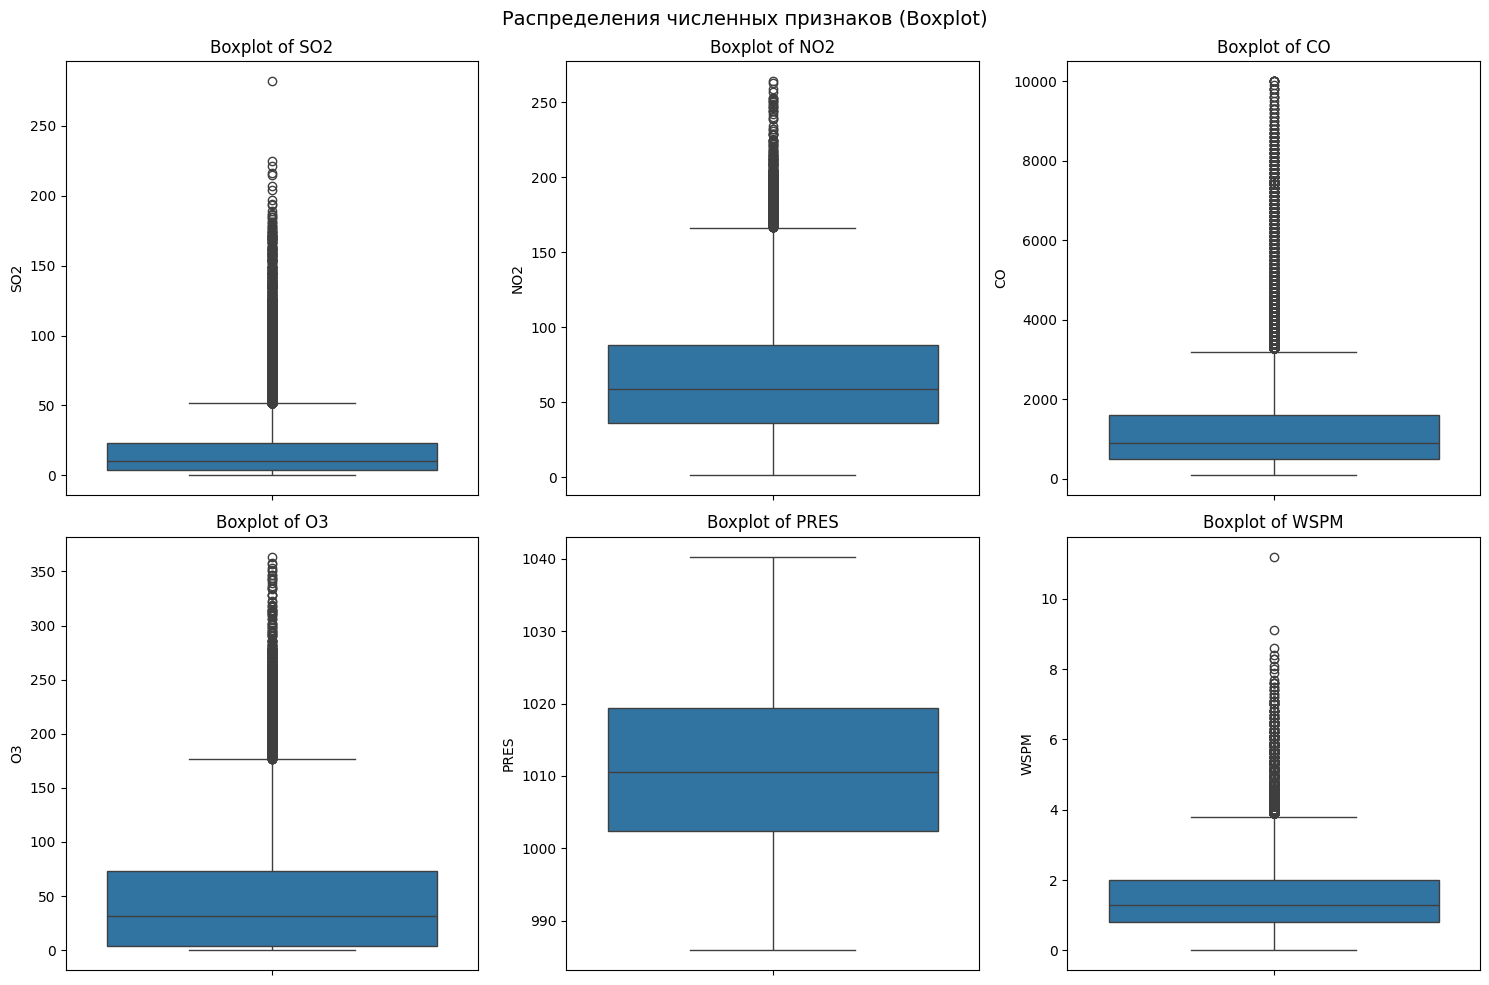

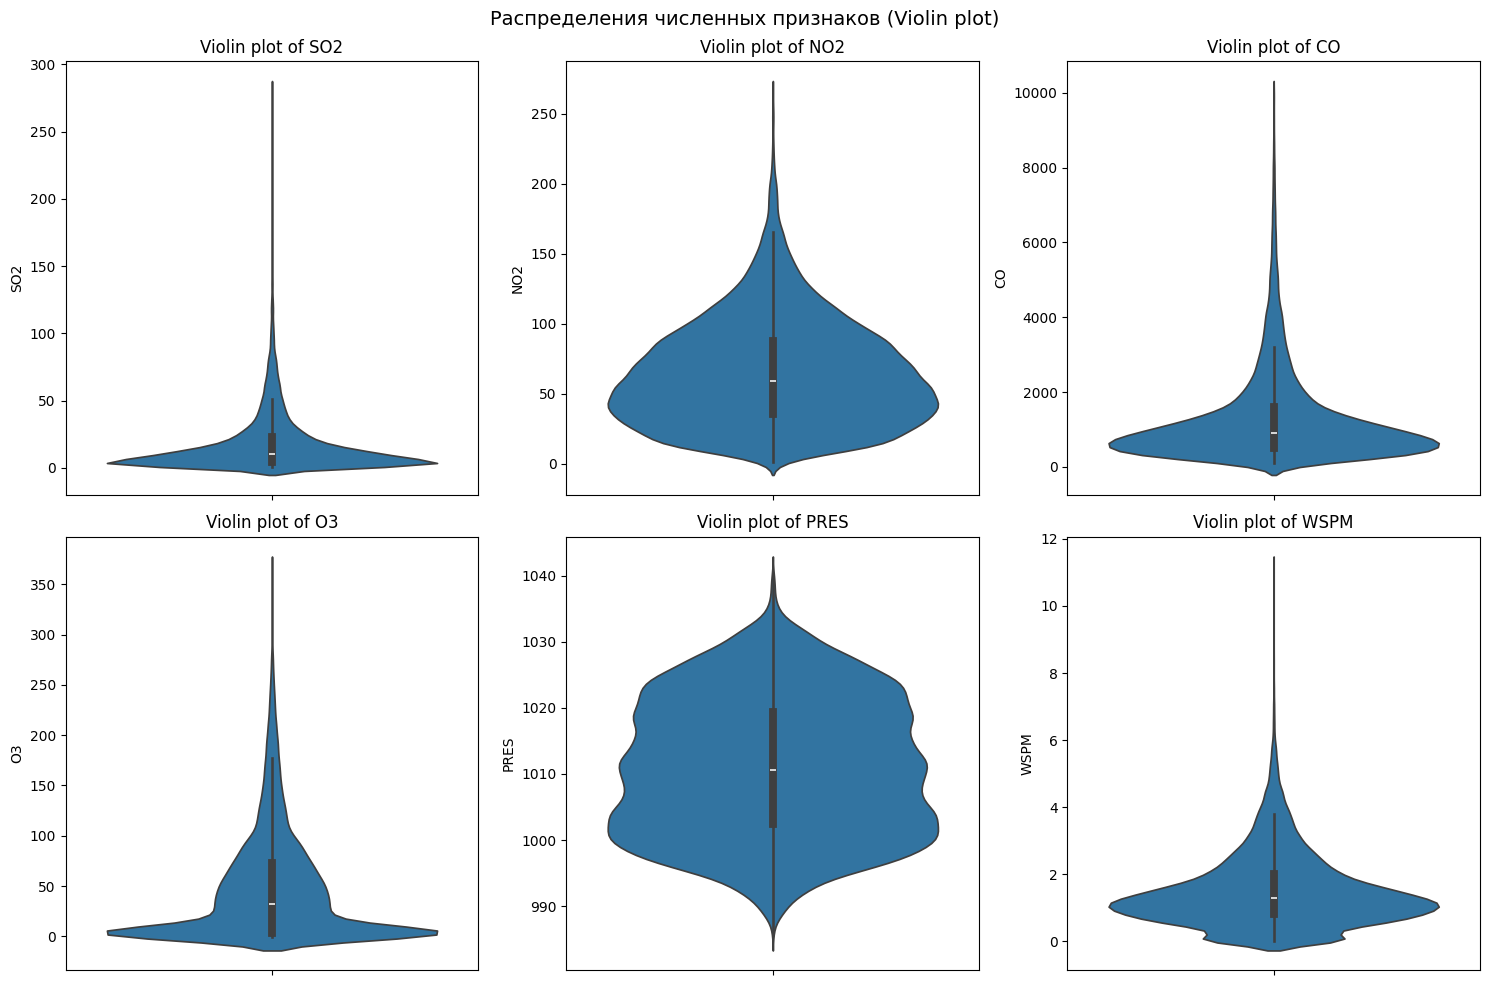

In [ ]:
numeric_cols = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM']

#Boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=prsa_data[col], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Boxplot of {col}')
plt.suptitle('Распределения численных признаков (Boxplot)', fontsize=14)
plt.tight_layout()
plt.show()

#Violin plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    sns.violinplot(y=prsa_data[col], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Violin plot of {col}')
plt.suptitle('Распределения численных признаков (Violin plot)', fontsize=14)
plt.tight_layout()
plt.show()

Boxplot позволяет увидеть медиану, квартили и выбросы. SO2, CO и O3 имеют длинные верхние хвосты - много выбросов выше верхнего квартиля. PRES распределен компактно, выбросы единичны. WSPM также имеет умеренный разброс.

Violin plot дополнительно показывает форму распределения: SO2 и CO имеют острый пик вблизи нуля с длинным хвостом вправо (правосторонняя асимметрия). O3 имеет два пика - около нуля и около 50. PRES близок к нормальному распределению.

2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.

In [ ]:
def adaptive_clipping(data, col, lower_percentile=1, upper_percentile=99):
    lower_bound = data[col].quantile(lower_percentile / 100)
    upper_bound = data[col].quantile(upper_percentile / 100)
    print(f"  {col}: нижняя граница={lower_bound:.2f}, верхняя граница={upper_bound:.2f}")
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
    return data

#к PRES и SO2
prsa_data = adaptive_clipping(prsa_data, 'PRES', lower_percentile=2, upper_percentile=98)
prsa_data = adaptive_clipping(prsa_data, 'SO2', lower_percentile=1, upper_percentile=99)

  PRES: нижняя граница=993.00, верхняя граница=1030.80
  SO2: нижняя граница=2.00, верхняя граница=108.02


Адаптивный клиппинг через процентили позволяет не задавать границы вручную. Для каждого признака автоматически вычисляются нижний (1-й или 2-й процентиль) и верхний (98-й или 99-й процентиль) порог. Все значения за этими границами заменяются граничными. Для PRES нижняя граница около 986, верхняя - около 1035. Для SO2 нижняя граница 0, верхняя - около 100. Форма распределения после клиппинга становится компактнее, "хвосты" обрезаются.

3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.

In [ ]:
print("Пропуски до заполнения:")
print(prsa_data[['SO2', 'NO2', 'CO', 'O3']].isnull().sum())

#заполним пропуски медианой
for col in ['SO2', 'NO2', 'CO', 'O3']:
    prsa_data[col] = prsa_data[col].fillna(prsa_data[col].median())

print("\nПропуски после заполнения:")
print(prsa_data[['SO2', 'NO2', 'CO', 'O3']].isnull().sum())

Пропуски до заполнения:
SO2     281
NO2     702
CO     1028
O3     1300
dtype: int64

Пропуски после заполнения:
SO2    0
NO2    0
CO     0
O3     0
dtype: int64


Для заполнения пропусков выбрана медиана - она устойчива к выбросам, которые присутствуют в SO2, NO2, CO и O3. В отличие от среднего, медиана не смещается под влиянием крайних значений. После заполнения во всех четырех столбцах пропусков не осталось. Метод прост и не вносит случайности в данные, что важно для воспроизводимости.

4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.

In [ ]:
#RobustScaler для признаков с выбросами
robust_scaler = RobustScaler()
prsa_data[['SO2', 'CO']] = robust_scaler.fit_transform(prsa_data[['SO2', 'CO']])

#StandardScaler для PRES
std_scaler = StandardScaler()
prsa_data[['PRES']] = std_scaler.fit_transform(prsa_data[['PRES']])

#MinMaxScaler для всего оставшегося
minmax_scaler = MinMaxScaler()
prsa_data[['NO2', 'O3', 'WSPM']] = minmax_scaler.fit_transform(prsa_data[['NO2', 'O3', 'WSPM']])

print("\nпосле нормализации:")
print(prsa_data[numeric_cols].describe().round(3))


после нормализации:
             SO2        NO2         CO         O3       PRES       WSPM
count  34180.000  34180.000  34180.000  34180.000  34180.000  34180.000
mean       0.419      0.241      0.452      0.133     -0.000      0.135
std        1.107      0.144      1.391      0.149      1.000      0.099
min       -0.421      0.000     -0.889      0.000     -1.763      0.000
25%       -0.316      0.131     -0.333      0.012     -0.844      0.071
50%        0.000      0.219      0.000      0.088     -0.043      0.116
75%        0.684      0.325      0.667      0.195      0.817      0.179
max        5.159      1.000     10.111      1.000      1.930      1.000


Для нормализации выбраны разные методы в зависимости от распределения признака:
- RobustScaler для SO2 и CO - эти признаки имеют выбросы, RobustScaler использует медиану и межквартильный размах, поэтому устойчив к ним.
- StandardScaler для PRES - распределение близко к нормальному, стандартизация здесь наиболее уместна.
- MinMaxScaler для NO2, O3, WSPM - эти признаки имеют ограниченный диапазон без сильных выбросов, масштабирование в [0, 1] сохраняет структуру распределения.

5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.

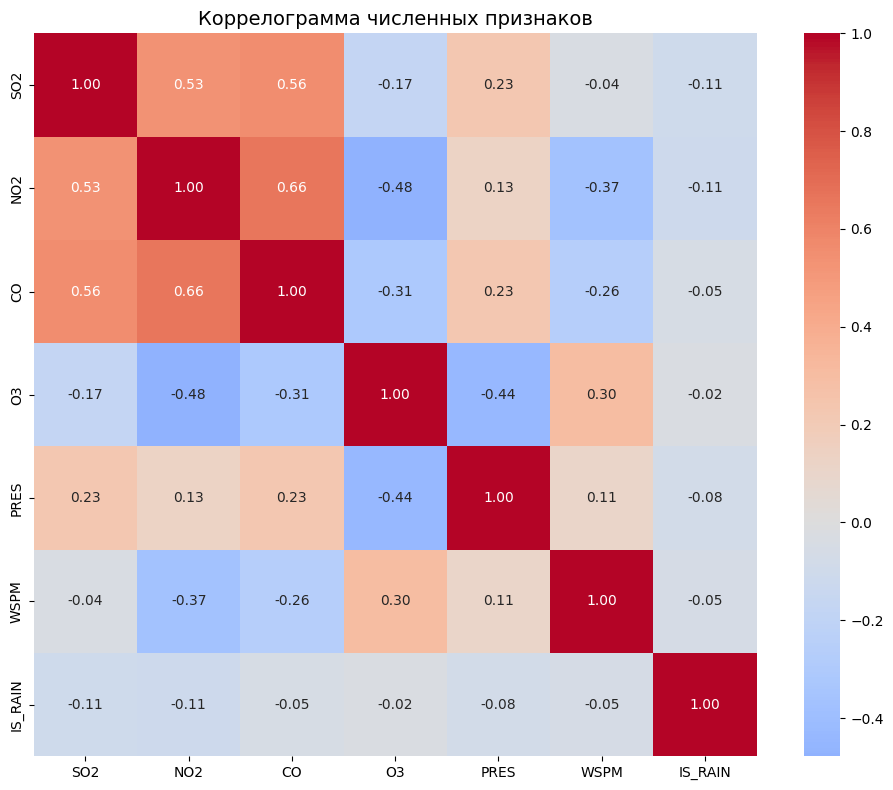

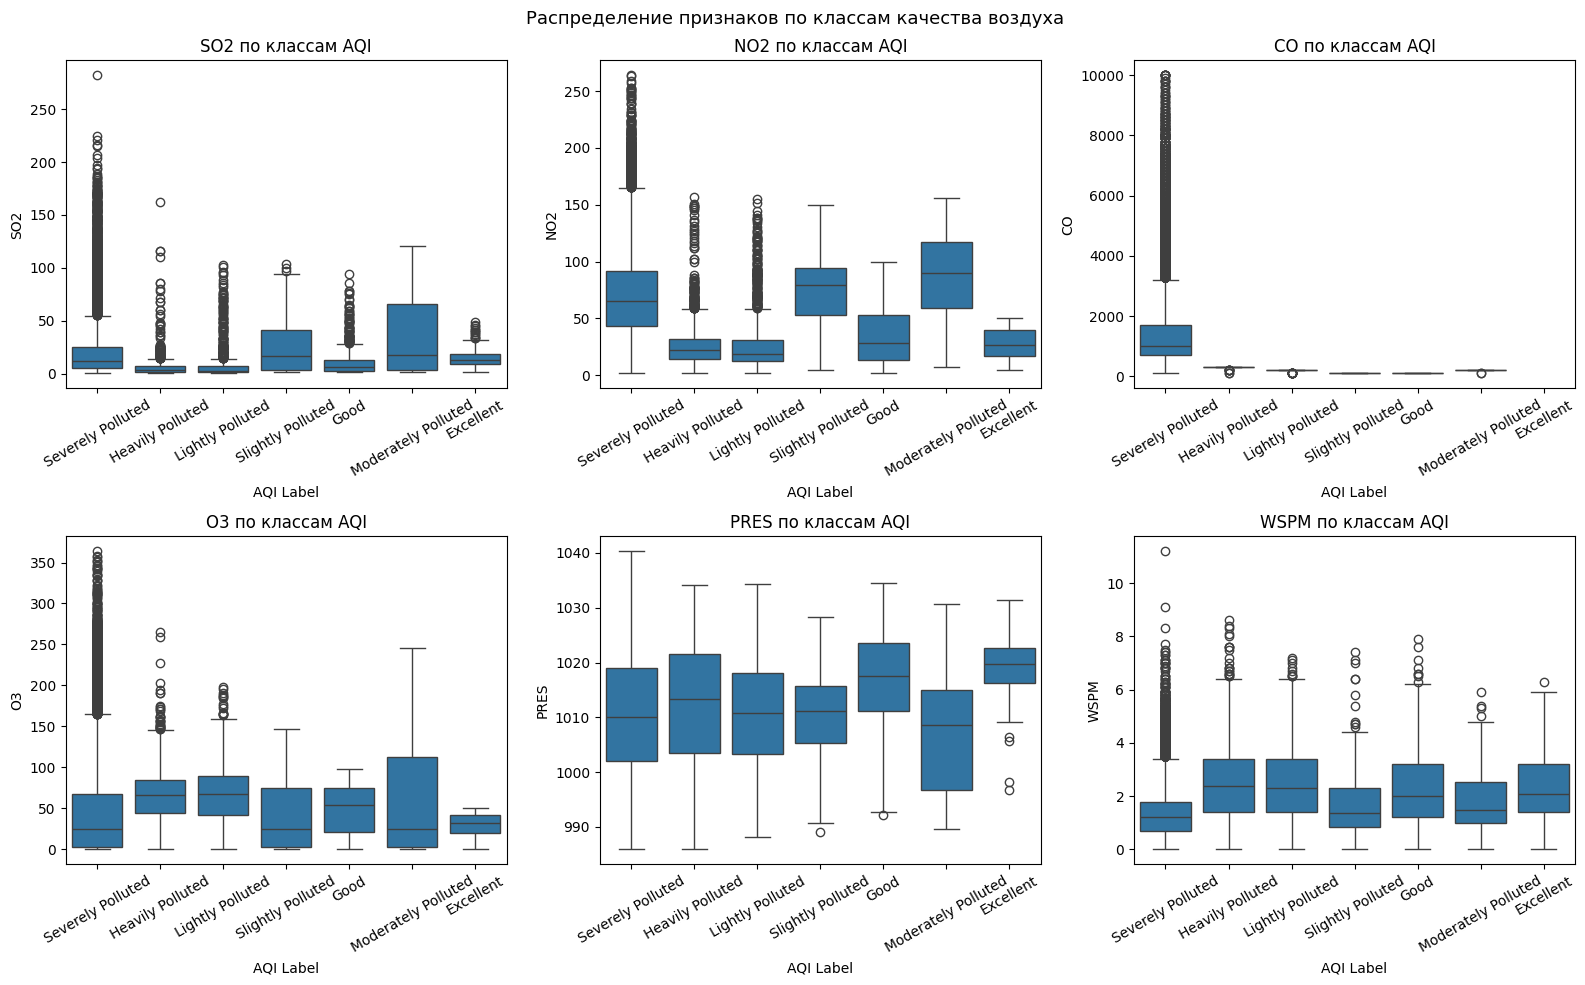

In [ ]:
numeric_for_corr = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'WSPM', 'IS_RAIN']
corr_matrix = prsa_data[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Коррелограмма численных признаков', fontsize=14)
plt.tight_layout()
plt.show()

# совместное распределение признаков с целевой переменной через boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=prsa_data, x='AQI Label', y=col, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} по классам AQI')
    axes[i//3, i%3].tick_params(axis='x', rotation=30)

plt.suptitle('Распределение признаков по классам качества воздуха', fontsize=13)
plt.tight_layout()
plt.show()

Boxplot по классам AQI позволяет оценить, как медиана и разброс признака меняются между классами. CO показывает наиболее четкое разделение: медианные значения заметно растут от класса "Excellent" к "Severely Polluted". NO2 также демонстрирует тенденцию роста с ухудшением качества воздуха. SO2 и O3 дают менее четкое разделение - распределения классов во многом перекрываются. PRES и WSPM практически не меняются между классами. Вывод: наиболее значимыми для классификации являются CO и NO2, группировка (дискретизация) оправдана прежде всего для CO.

6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.

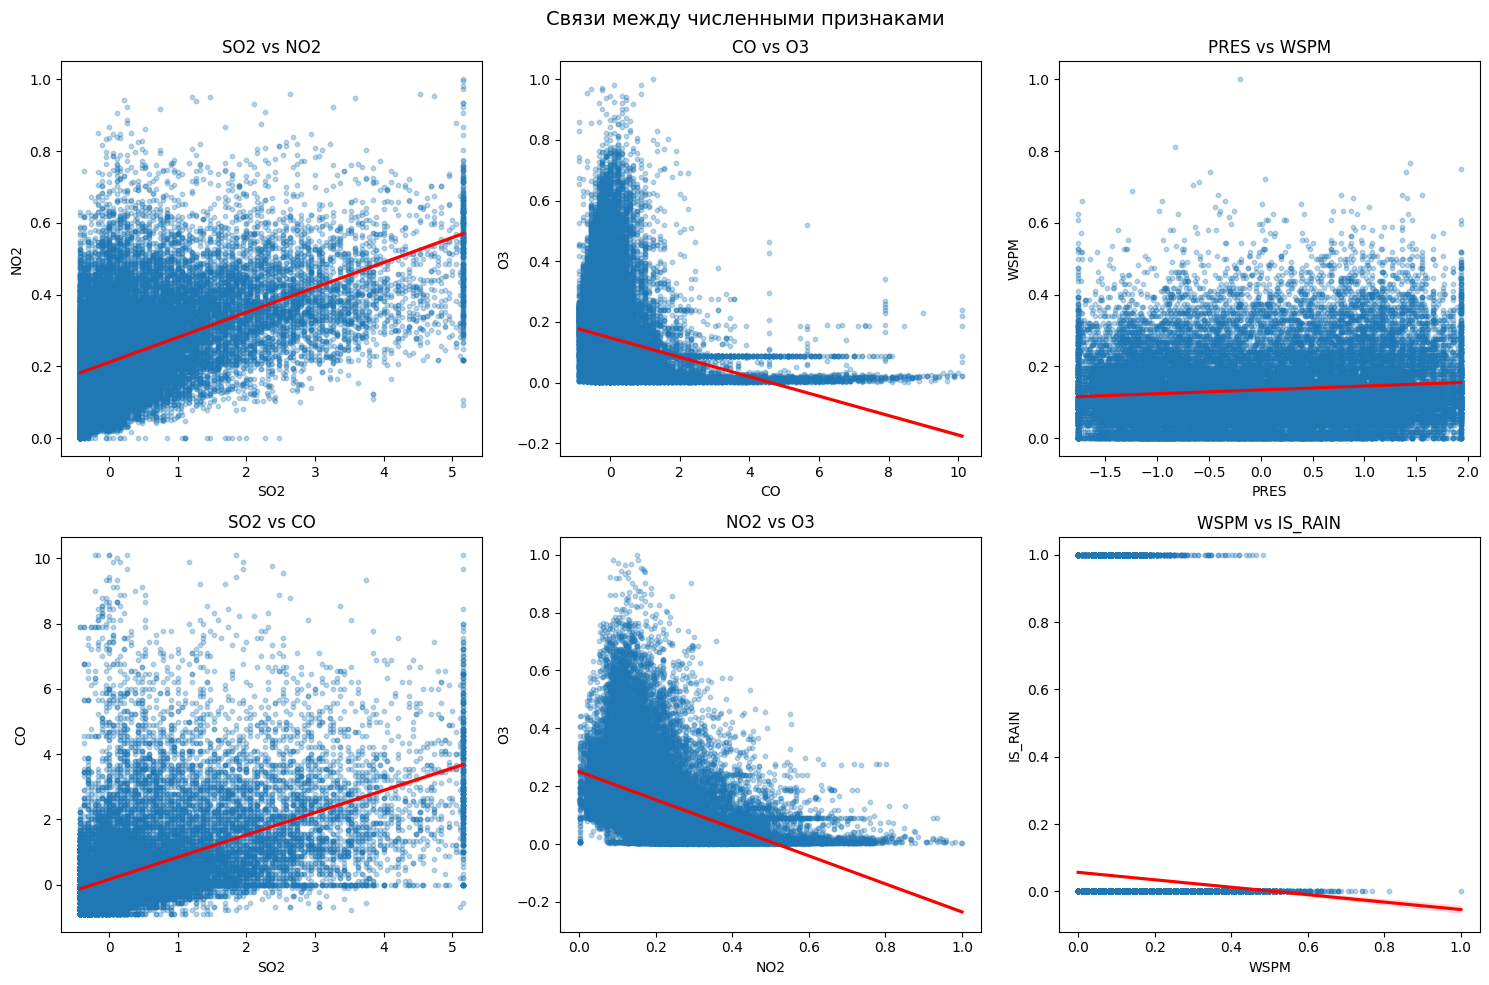

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pairs = [('SO2', 'NO2'), ('CO', 'O3'), ('PRES', 'WSPM'), ('SO2', 'CO'), ('NO2', 'O3'), ('WSPM', 'IS_RAIN')]

for i, (x, y) in enumerate(pairs):
    sns.regplot(x=prsa_data[x], y=prsa_data[y], ax=axes[i//3, i%3],
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color': 'red'})
    axes[i//3, i%3].set_title(f'{x} vs {y}')
    axes[i//3, i%3].set_xlabel(x)
    axes[i//3, i%3].set_ylabel(y)

plt.suptitle('Связи между численными признаками', fontsize=14)
plt.tight_layout()
plt.show()

На графиках регрессии видно:
- SO2 и NO2 - умеренная положительная зависимость, облако точек вытянуто по диагонали.
- CO и O3 - слабая отрицательная зависимость: при высоких CO концентрация O3 ниже.
- PRES и WSPM - зависимость практически отсутствует, облако точек равномерное.
- SO2 и CO - заметная положительная зависимость, аналогично коррелограмме.
- NO2 и O3 - слабая отрицательная зависимость.
- WSPM и IS_RAIN - при наличии осадков скорость ветра незначительно выше, но связь слабая.
Вывод: наиболее зависимы между собой признаки одной химической природы (SO2, NO2, CO). O3 ведет себя противоположно им, что подтверждает его иную роль в химии атмосферы.